# 06 — Presentation Figures

Builds the figure set for the conference talk,
**"Bayes-ed on a True Story: Does Affordable Housing Raise Rents?"**

This notebook does no sampling. It reads the saved panels and posterior
summaries written by notebooks 04 and 05, fits a fast per-state OLS baseline
for the no-pooling comparison, and writes seven slide-ready figures to
`reports/figures/presentation/`.

| Fig | Slide | Argument it carries |
|-----|-------|---------------------|
| F1 | 3. The shape of the data | Coverage is wildly uneven across states |
| F2 | 4. The familiar model | One national slope describes almost no county |
| F3 | 5. The obvious fix | Fitting states separately blows up where data is thin |
| F4 | 6. Partial pooling | Shrinkage pulls thin-data states toward the national mean |
| F5 | 7. What changed | State slopes for home values, split into three tiers |
| F6 | 7. What changed | Same for rents |
| F7 | 7. What changed | Tier summary and the count of states consistent with the national estimate |

Run order: `01` → `02` → `03` → `04` → `05` → **`06`**

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# ---------------------------------------------------------------- paths
PANEL_DIR = '../data/processed'
SUMM_DIR  = '../reports/summaries'
OUT_DIR   = '../reports/figures/presentation'
os.makedirs(OUT_DIR, exist_ok=True)

# ---------------------------------------------------------------- style
# Slide-grade defaults. Large type, no top/right spines, no grid clutter.
plt.rcParams.update({
    'figure.dpi':        120,
    'savefig.dpi':       200,
    'savefig.bbox':      'tight',
    'font.size':         13,
    'axes.titlesize':    17,
    'axes.labelsize':    14,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.titlepad':     34,
    'xtick.labelsize':   11,
    'ytick.labelsize':   11,
    'legend.frameon':    False,
})

# Colour encodes DIRECTION of the state slope only, nothing normative.
C_POS  = '#B04A39'   # credibly positive
C_ZERO = '#8C8C8C'   # 95% HDI overlaps zero
C_NEG  = '#2D6E7E'   # credibly negative
C_INK  = '#1A1A1A'   # reference lines, national estimate
C_MUTE = '#D6D2CB'   # background scatter

def save(fig, name):
    path = f'{OUT_DIR}/{name}.png'
    fig.savefig(path)
    print(f'  wrote {path}')
    return path

## Step 1 — Load the saved panels and posterior summaries

Nothing here re-runs a model. `04` and `05` wrote the analysis panels with every
engineered column, plus `az.summary()` output for the parameters we need.

In [2]:
housing = pd.read_csv(f'{PANEL_DIR}/housing_analysis_panel.csv',
                      dtype={'county_fips': str})
rental  = pd.read_csv(f'{PANEL_DIR}/rental_analysis_panel.csv',
                      dtype={'county_fips': str})

h_slopes = pd.read_csv(f'{SUMM_DIR}/housing_state_slopes.csv', index_col='State')
r_slopes = pd.read_csv(f'{SUMM_DIR}/rental_state_slopes.csv',  index_col='State')
h_hyper  = pd.read_csv(f'{SUMM_DIR}/housing_hyperparams.csv',  index_col=0)
r_hyper  = pd.read_csv(f'{SUMM_DIR}/rental_hyperparams.csv',   index_col=0)
# The pooled model is used only to draw the national line in F2.
# If notebook 04 did not save it, fall back to OLS on the full panel:
# with vague priors the two agree closely, and F2 is a visual reference.
_pp = f'{SUMM_DIR}/housing_pooled.csv'
if os.path.exists(_pp):
    h_pooled = pd.read_csv(_pp, index_col=0)
    POOLED_SRC = 'saved Bayesian pooled model'
else:
    _d = housing.dropna(subset=['log_zhvi_adj', 'log_lihtc_per_1k', 'pop_growth'])
    _X = np.column_stack([np.ones(len(_d)),
                          _d['log_lihtc_per_1k'].to_numpy(),
                          _d['pop_growth'].to_numpy()])
    _b, *_ = np.linalg.lstsq(_X, _d['log_zhvi_adj'].to_numpy(), rcond=None)
    h_pooled = pd.DataFrame(
        {'mean': [_b[0], _b[1], _b[2], np.nan]},
        index=['beta0_intercept', 'beta1_sqrt_ma', 'gamma', 'tau'])
    POOLED_SRC = 'OLS fallback (housing_pooled.csv not found)'

# National (hyperprior mean) slope for each outcome
MU_H = float(h_hyper.loc['mu_beta', 'mean'])
MU_R = float(r_hyper.loc['mu_beta', 'mean'])

print(f'housing panel : {housing.shape[0]:>6,} rows  '
      f'{housing.county_fips.nunique():>5,} counties  '
      f'{housing.State.nunique():>3} states')
print(f'rental panel  : {rental.shape[0]:>6,} rows  '
      f'{rental.county_fips.nunique():>5,} counties  '
      f'{rental.State.nunique():>3} states')
print(f'\nnational slope, home values : {MU_H:+.4f}')
print(f'national slope, rents       : {MU_R:+.4f}')
print(f'pooled line for F2          : {POOLED_SRC}')

housing panel : 11,481 rows  2,073 counties   50 states
rental panel  :  2,516 rows    610 counties   50 states

national slope, home values : +0.1260
national slope, rents       : +0.3750
pooled line for F2          : saved Bayesian pooled model


## Step 2 — F1: the shape of the data

The argument for slide 3. Coverage is not close to uniform. A handful of states
carry hundreds of county-year observations while the thin tail has a few dozen.
That imbalance is the whole reason the next two models behave the way they do,
so this figure comes before any modelling.

  wrote ../reports/figures/presentation/F1_coverage_by_state.png


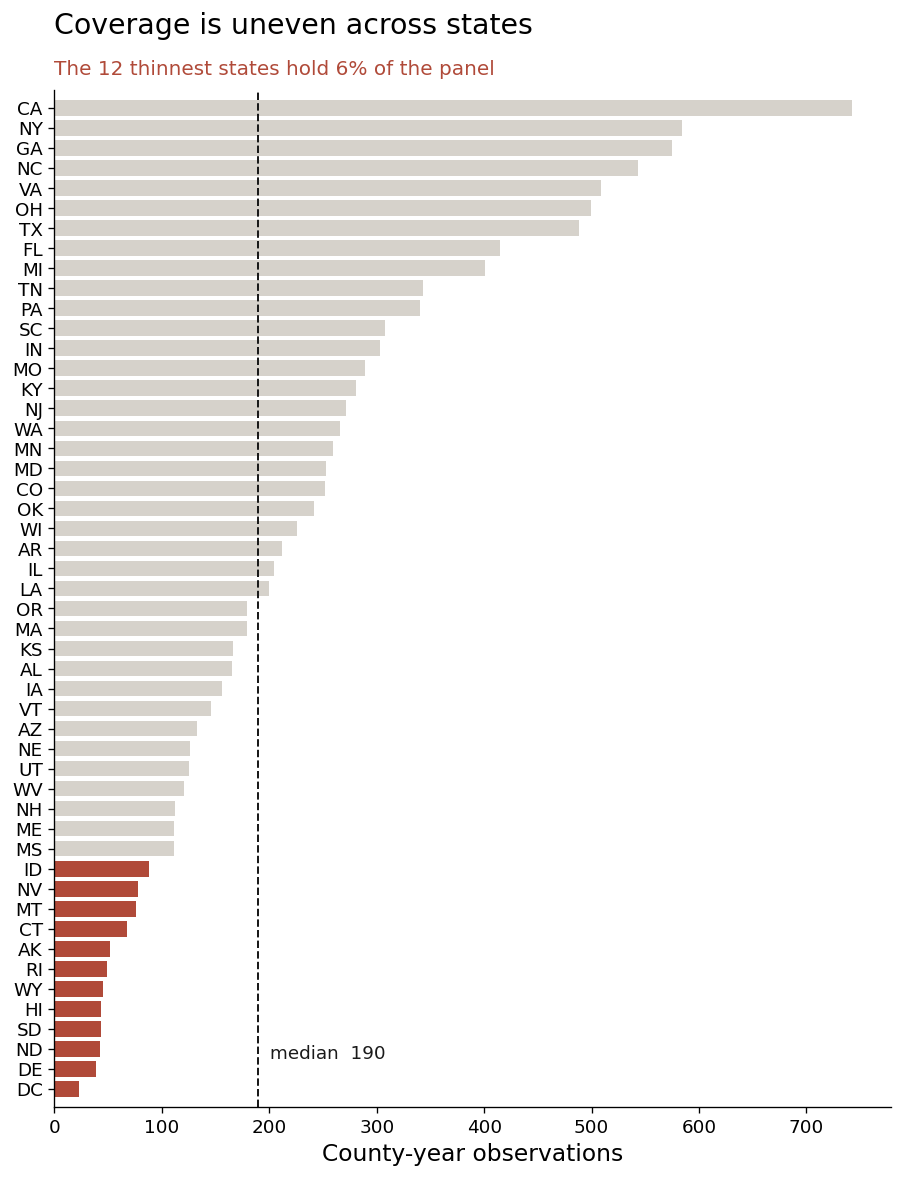

In [3]:
obs = (housing.groupby('State')
               .agg(n_obs=('county_fips', 'size'),
                    n_cty=('county_fips', 'nunique'))
               .sort_values('n_obs'))

THIN = 12   # highlight the thinnest states

fig, ax = plt.subplots(figsize=(9, 11))
colors = [C_POS if i < THIN else C_MUTE for i in range(len(obs))]
ax.barh(obs.index, obs['n_obs'], color=colors, height=0.78)

med = obs['n_obs'].median()
ax.axvline(med, color=C_INK, lw=1.2, ls='--')
ax.text(med * 1.06, 1.5, f'median  {med:,.0f}', color=C_INK, fontsize=11)

ax.set_xlabel('County-year observations')
ax.set_title('Coverage is uneven across states', loc='left')
ax.text(0, 1.015,
        f'The {THIN} thinnest states hold '
        f'{obs["n_obs"].head(THIN).sum() / obs["n_obs"].sum():.0%} of the panel',
        transform=ax.transAxes, fontsize=12, color=C_POS)
ax.margins(y=0.01)
save(fig, 'F1_coverage_by_state')
plt.show()

## Step 3 — F2: what one national slope actually looks like

Slide 4. The pooled model fits a single line through every county-year. Drawing
that line over the raw scatter, alongside a few state-specific fits, makes the
problem visible without any statistics vocabulary: the national line runs through
the middle of a fan, and the fan is the interesting part.

`pop_growth` is held at its panel mean so the line is drawn in two dimensions.

  wrote ../reports/figures/presentation/F2_pooled_slope_over_scatter.png


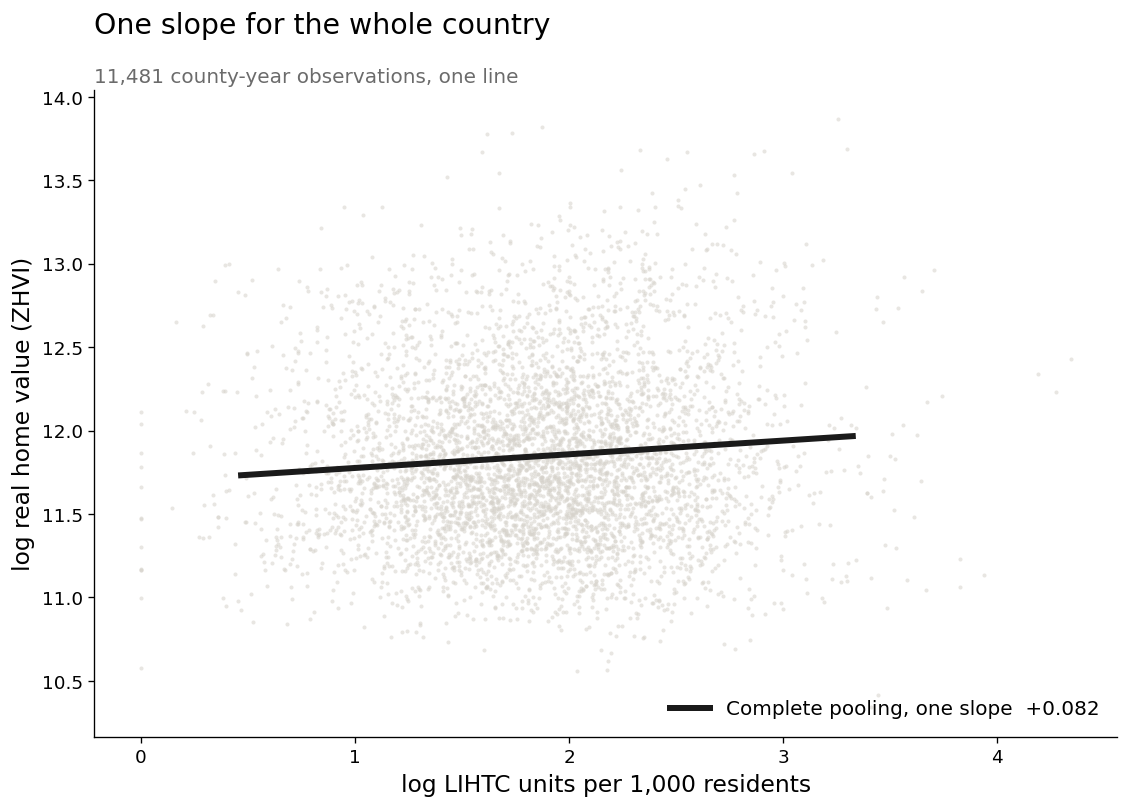

In [4]:
B0   = float(h_pooled.loc['beta0_intercept', 'mean'])
B1   = float(h_pooled.loc['beta1_sqrt_ma',    'mean'])
GAM  = float(h_pooled.loc['gamma',            'mean'])
PGBAR = housing['pop_growth'].mean()

samp = housing.sample(min(5000, len(housing)), random_state=6420)
xs = np.linspace(housing['log_lihtc_per_1k'].quantile(0.01),
                 housing['log_lihtc_per_1k'].quantile(0.99), 100)

fig, ax = plt.subplots(figsize=(11, 7))
ax.scatter(samp['log_lihtc_per_1k'], samp['log_zhvi_adj'],
           s=6, color=C_MUTE, alpha=0.55, linewidths=0, zorder=1)

# A few states fitted on their own, to show the spread the pooled line hides
# for st, col in [('HI', C_POS), ('CO', C_POS), ('CA', C_POS),
#                 ('OH', C_NEG), ('IL', C_NEG)]:
#     sub = housing[housing.State == st]
#     if len(sub) < 10:
#         continue
#     b = np.polyfit(sub['log_lihtc_per_1k'], sub['log_zhvi_adj'], 1)
#     ax.plot(xs, np.polyval(b, xs), color=col, lw=2.0, alpha=0.85, zorder=2)
#     ax.annotate(st, (xs[-1], np.polyval(b, xs[-1])),
#                 xytext=(6, -4), textcoords='offset points',
#                 color=col, fontsize=12, fontweight='bold')

ax.plot(xs, B0 + B1 * xs + GAM * PGBAR,
        color=C_INK, lw=3.6, zorder=3,
        label=f'Complete pooling, one slope  {B1:+.3f}')

ax.set_xlabel('log LIHTC units per 1,000 residents')
ax.set_ylabel('log real home value (ZHVI)')
ax.set_title('One slope for the whole country', loc='left')
ax.text(0, 1.012, f'{len(housing):,} county-year observations, one line',
        transform=ax.transAxes, fontsize=12, color='#6B6B6B')
ax.legend(loc='lower right', fontsize=12)
save(fig, 'F2_pooled_slope_over_scatter')
plt.show()

## Step 4 — Fit the no-pooling baseline

Slide 5 needs the model most of the audience would reach for first: fit each
state on its own. This is ordinary least squares, one regression per state, same
specification as the hierarchical model.

`np.linalg.lstsq` keeps this dependency-free and it runs in under a second.
Standard errors come from the usual `sigma^2 (X'X)^-1`.

In [5]:
def ols_within(Xw, yw, dof):
    """OLS on county-demeaned data. No intercept: demeaning removes it."""
    beta, *_ = np.linalg.lstsq(Xw, yw, rcond=None)
    if dof <= 0:
        return beta, np.full(len(beta), np.nan)
    resid = yw - Xw @ beta
    sigma2 = (resid @ resid) / dof
    se = np.sqrt(np.diag(sigma2 * np.linalg.pinv(Xw.T @ Xw)))
    return beta, se


def fit_no_pooling(panel, ycol, min_dof=8):
    """
    Fit each state on its own, with COUNTY FIXED EFFECTS.

    The hierarchical model gives every county its own intercept. To make the
    no-pooling estimate comparable, each state regression must do the same,
    otherwise the slope absorbs cross-county differences in price level and
    the comparison in F4 is meaningless.

    County fixed effects are applied by the within transformation: subtract
    each county's mean from every column, then regress without an intercept.
    Counties with a single observation contribute nothing and drop out.
    """
    cols = [ycol, 'log_lihtc_per_1k', 'pop_growth']
    rows = []
    for st, sub in panel.groupby('State'):
        sub = sub.dropna(subset=cols)
        g = sub.groupby('county_fips')
        keep = g[ycol].transform('size') > 1          # need within-county variation
        sub, gk = sub[keep], sub[keep].groupby('county_fips')
        n_obs, n_cty = len(sub), sub['county_fips'].nunique()
        dof = n_obs - n_cty - 2
        if dof < min_dof:
            rows.append({'State': st, 'n_obs': n_obs, 'n_cty': n_cty,
                         'slope': np.nan, 'se': np.nan})
            continue
        w = sub[cols] - gk[cols].transform('mean')
        b, se = ols_within(w[['log_lihtc_per_1k', 'pop_growth']].to_numpy(),
                           w[ycol].to_numpy(), dof)
        rows.append({'State': st, 'n_obs': n_obs, 'n_cty': n_cty,
                     'slope': b[0], 'se': se[0]})

    out = pd.DataFrame(rows).set_index('State')
    out['lo'] = out['slope'] - 1.96 * out['se']
    out['hi'] = out['slope'] + 1.96 * out['se']
    out['ci_width'] = out['hi'] - out['lo']
    return out


nopool = fit_no_pooling(housing, 'log_zhvi_adj')
nopool = nopool.join(h_slopes[['mean']].rename(columns={'mean': 'partial'}))

print(f'fitted {nopool.slope.notna().sum()} states with county fixed effects\n')
print('widest intervals (thinnest data):')
print(nopool.nsmallest(6, 'n_obs')[['n_obs', 'n_cty', 'slope', 'ci_width']]
      .to_string(float_format=lambda v: f'{v:.3f}'))
print('\nnarrowest intervals (richest data):')
print(nopool.nlargest(6, 'n_obs')[['n_obs', 'n_cty', 'slope', 'ci_width']]
      .to_string(float_format=lambda v: f'{v:.3f}'))
print(f"\nmean |no-pool - partial| gap: "
      f"{(nopool.slope - nopool.partial).abs().mean():.3f}")

fitted 50 states with county fixed effects

widest intervals (thinnest data):
       n_obs  n_cty  slope  ci_width
State                               
DC        23      1  0.442     0.176
DE        39      3  0.067     0.367
ND        39      9  0.270     0.489
SD        40      8  0.435     0.424
WY        40     12  0.648     0.340
HI        43      4  0.392     0.240

narrowest intervals (richest data):
       n_obs  n_cty  slope  ci_width
State                               
CA       739     51  0.166     0.125
NY       582     58  0.144     0.050
GA       542    105  0.157     0.113
NC       531     73  0.125     0.081
OH       490     74 -0.132     0.095
VA       486     74  0.119     0.070

mean |no-pool - partial| gap: 0.058


/var/folders/jk/6_scppq56zb3dhlb6yfjslmr0000gn/T/ipykernel_44369/1705290064.py:6: RuntimeWarning: divide by zero encountered in matmul
  resid = yw - Xw @ beta
/var/folders/jk/6_scppq56zb3dhlb6yfjslmr0000gn/T/ipykernel_44369/1705290064.py:6: RuntimeWarning: overflow encountered in matmul
  resid = yw - Xw @ beta
/var/folders/jk/6_scppq56zb3dhlb6yfjslmr0000gn/T/ipykernel_44369/1705290064.py:6: RuntimeWarning: invalid value encountered in matmul
  resid = yw - Xw @ beta
/var/folders/jk/6_scppq56zb3dhlb6yfjslmr0000gn/T/ipykernel_44369/1705290064.py:6: RuntimeWarning: divide by zero encountered in matmul
  resid = yw - Xw @ beta
/var/folders/jk/6_scppq56zb3dhlb6yfjslmr0000gn/T/ipykernel_44369/1705290064.py:6: RuntimeWarning: overflow encountered in matmul
  resid = yw - Xw @ beta
/var/folders/jk/6_scppq56zb3dhlb6yfjslmr0000gn/T/ipykernel_44369/1705290064.py:6: RuntimeWarning: invalid value encountered in matmul
  resid = yw - Xw @ beta
/var/folders/jk/6_scppq56zb3dhlb6yfjslmr0000gn/T/ipyke

In [6]:
lvl = housing.groupby('State')['log_zhvi_adj'].mean().rename('mean_log_price')
chk = nopool.join(lvl)
chk['gap'] = chk['partial'] - chk['slope']
chk = chk.dropna(subset=['gap'])

r = chk['gap'].corr(chk['mean_log_price'])
print(f'corr(gap, state price level) = {r:+.3f}\n')
print(chk.sort_values('mean_log_price', ascending=False)
         .head(8)[['mean_log_price', 'slope', 'partial', 'gap', 'n_obs']]
         .to_string(float_format=lambda v: f'{v:.3f}'))
print()
print(chk.sort_values('mean_log_price')
         .head(8)[['mean_log_price', 'slope', 'partial', 'gap', 'n_obs']]
         .to_string(float_format=lambda v: f'{v:.3f}'))

corr(gap, state price level) = +0.084

       mean_log_price  slope  partial    gap  n_obs
State                                              
HI             12.853  0.392    0.384 -0.008     43
DC             12.682  0.442    0.360 -0.082     23
CA             12.584  0.166    0.212  0.046    739
MA             12.423 -0.021    0.004  0.025    178
NJ             12.359 -0.029   -0.030 -0.001    270
CO             12.331  0.327    0.378  0.051    237
RI             12.290  0.109    0.129  0.020     49
CT             12.240 -0.311   -0.166  0.145     68

       mean_log_price  slope  partial    gap  n_obs
State                                              
WV             11.315 -0.010    0.011  0.021    103
OK             11.317  0.051    0.052  0.001    231
KS             11.412  0.359    0.151 -0.208    146
AR             11.416  0.003   -0.006 -0.009    201
KY             11.453  0.029    0.032  0.003    241
MS             11.458  0.266    0.060 -0.206     95
OH             11.468 -0

In [7]:
lvl = housing.groupby('State')['log_zhvi_adj'].mean().rename('mean_log_price')
chk = nopool.join(lvl)
chk['gap'] = chk['partial'] - chk['slope']
chk = chk.dropna(subset=['gap'])

r = chk['gap'].corr(chk['mean_log_price'])
print(f'corr(gap, state price level) = {r:+.3f}   (was +0.382)\n')

print('highest-price states:')
print(chk.sort_values('mean_log_price', ascending=False)
         .head(8)[['mean_log_price', 'slope', 'partial', 'gap', 'n_obs']]
         .to_string(float_format=lambda v: f'{v:.3f}'))

print('\nlowest-price states:')
print(chk.sort_values('mean_log_price')
         .head(8)[['mean_log_price', 'slope', 'partial', 'gap', 'n_obs']]
         .to_string(float_format=lambda v: f'{v:.3f}'))

print('\nthe five that disagreed most:')
print(chk.loc[[s for s in ['CT', 'MA', 'NJ', 'KS', 'MS'] if s in chk.index],
              ['slope', 'partial', 'gap', 'n_obs']]
         .to_string(float_format=lambda v: f'{v:.3f}'))

corr(gap, state price level) = +0.084   (was +0.382)

highest-price states:
       mean_log_price  slope  partial    gap  n_obs
State                                              
HI             12.853  0.392    0.384 -0.008     43
DC             12.682  0.442    0.360 -0.082     23
CA             12.584  0.166    0.212  0.046    739
MA             12.423 -0.021    0.004  0.025    178
NJ             12.359 -0.029   -0.030 -0.001    270
CO             12.331  0.327    0.378  0.051    237
RI             12.290  0.109    0.129  0.020     49
CT             12.240 -0.311   -0.166  0.145     68

lowest-price states:
       mean_log_price  slope  partial    gap  n_obs
State                                              
WV             11.315 -0.010    0.011  0.021    103
OK             11.317  0.051    0.052  0.001    231
KS             11.412  0.359    0.151 -0.208    146
AR             11.416  0.003   -0.006 -0.009    201
KY             11.453  0.029    0.032  0.003    241
MS             11.

## Step 5 — F3: what fitting states separately costs you

Sorted by sample size so the relationship reads top to bottom. The left panel is
the estimate with its 95% interval, the right panel is how much data the state
had. Thin states produce intervals wide enough to be useless.

  wrote ../reports/figures/presentation/F3_no_pooling_estimates.png


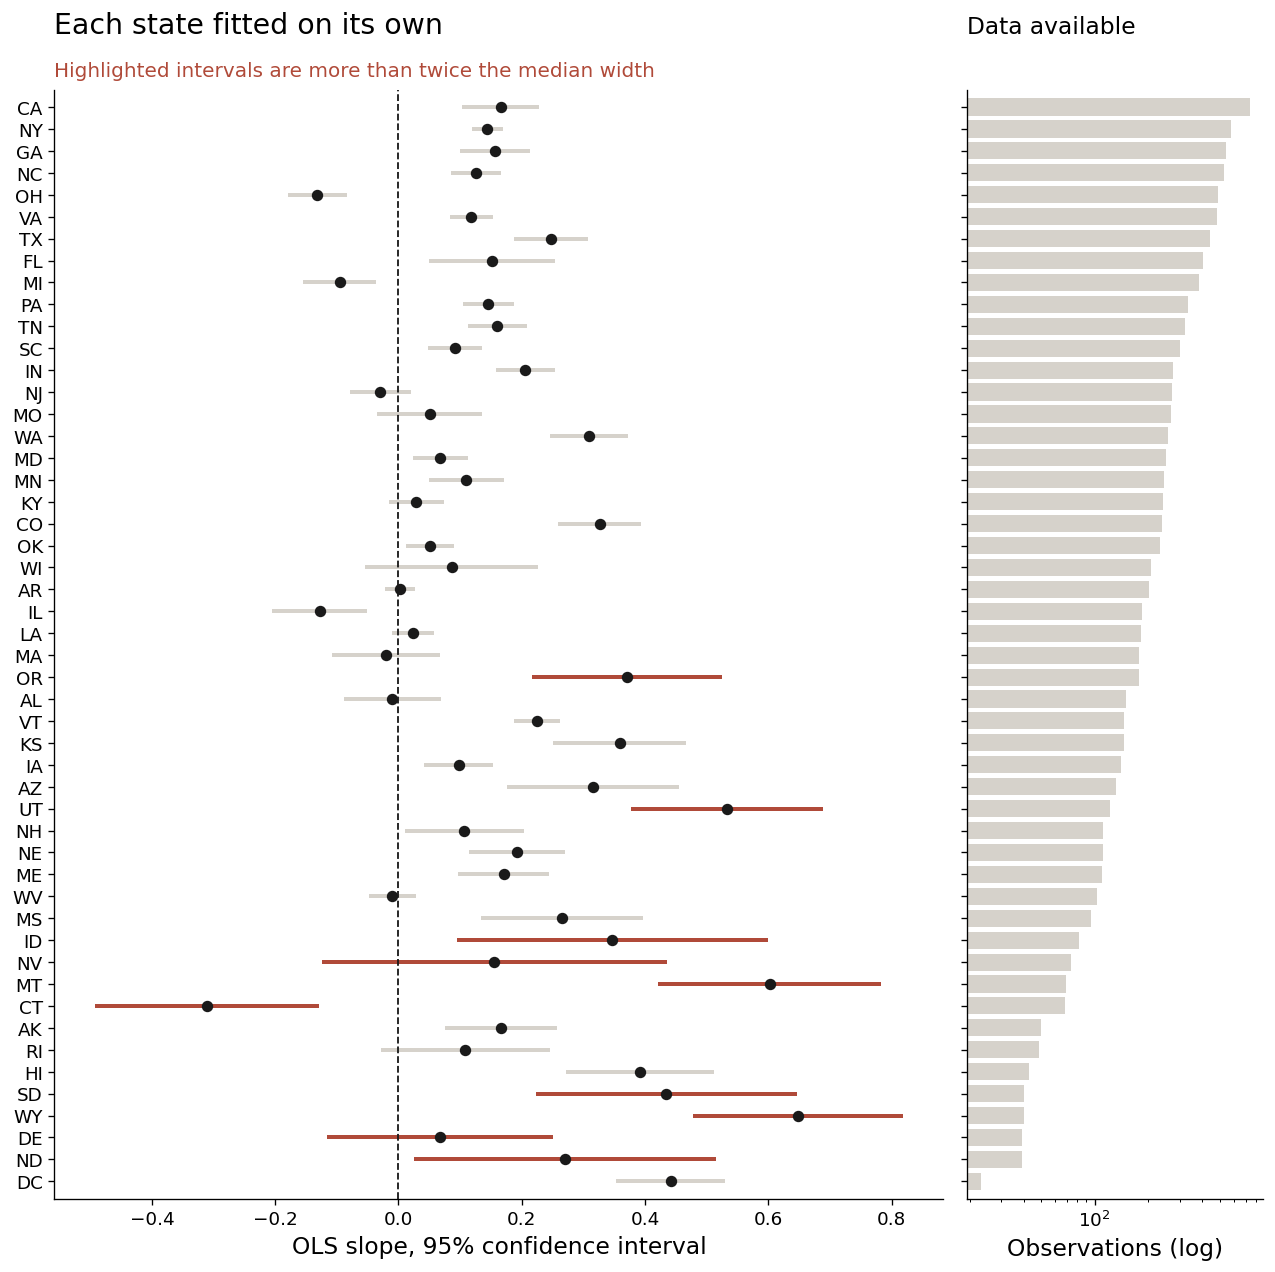

In [8]:
d = nopool.dropna(subset=['slope']).sort_values('n_obs')

fig, (axL, axR) = plt.subplots(
    1, 2, figsize=(13, 12), sharey=True,
    gridspec_kw={'width_ratios': [3, 1], 'wspace': 0.04})

ypos = np.arange(len(d))
wide = d['ci_width'] > d['ci_width'].median() * 2
cols = np.where(wide, C_POS, C_MUTE)

axL.errorbar(d['slope'], ypos,
             xerr=[d['slope'] - d['lo'], d['hi'] - d['slope']],
             fmt='none', ecolor=cols, elinewidth=2.4, capsize=0, zorder=1)
axL.scatter(d['slope'], ypos, s=34, color=C_INK, zorder=2)
axL.axvline(0, color=C_INK, lw=1.1, ls='--')
axL.set_yticks(ypos)
axL.set_yticklabels(d.index)
axL.set_xlabel('OLS slope, 95% confidence interval')
axL.set_title('Each state fitted on its own', loc='left')
axL.margins(y=0.008)

axR.barh(ypos, d['n_obs'], color=C_MUTE, height=0.78)
axR.set_xscale('log')
axR.set_xlabel('Observations (log)')
axR.set_title('Data available', loc='left', fontsize=14)
axR.margins(y=0.008)

axL.text(0, 1.012,
        'Highlighted intervals are more than twice the median width',
        transform=axL.transAxes, fontsize=12, color=C_POS)
save(fig, 'F3_no_pooling_estimates')
plt.show()

## Step 6 — F4: the shrinkage plot

The single most important figure in the deck. Each point is a state. The
horizontal position is what the state said on its own, the vertical position is
what the hierarchical model concluded once the state borrowed strength from the
national distribution.

Points on the diagonal were left alone. Points pulled toward the horizontal line
are states the model did not believe, and they are the small ones.

  wrote ../reports/figures/presentation/F4_shrinkage.png


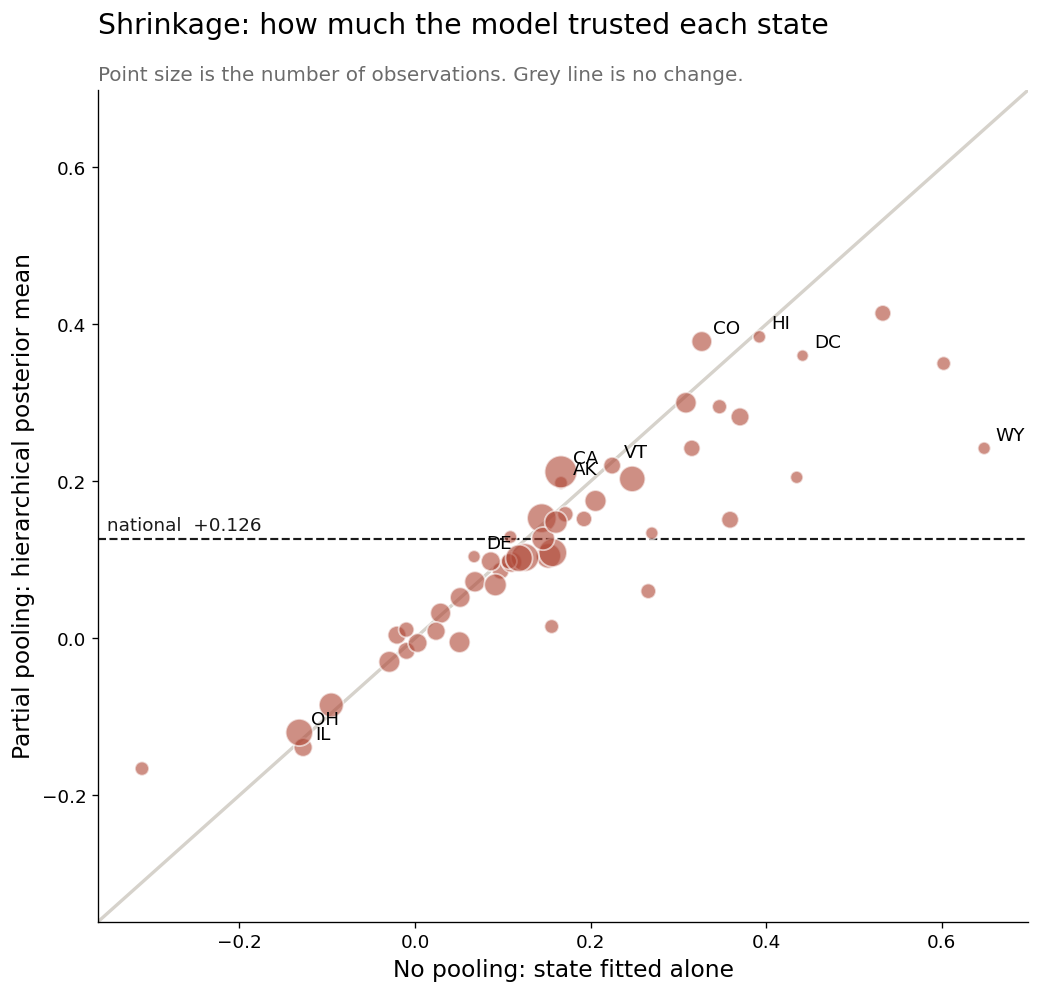

In [9]:
d = nopool.dropna(subset=['slope', 'partial']).copy()
sz = 40 + 340 * (d['n_obs'] / d['n_obs'].max())

fig, ax = plt.subplots(figsize=(10, 9))
lim = [min(d.slope.min(), d.partial.min()) - 0.05,
       max(d.slope.max(), d.partial.max()) + 0.05]

ax.plot(lim, lim, color=C_MUTE, lw=2, ls='-', zorder=1)
ax.axhline(MU_H, color=C_INK, lw=1.3, ls='--', zorder=1)
ax.text(lim[0] + 0.01, MU_H + 0.012,
        f'national  {MU_H:+.3f}', color=C_INK, fontsize=11)

ax.scatter(d['slope'], d['partial'], s=sz, color=C_POS,
           alpha=0.62, edgecolor='white', linewidth=1.1, zorder=3)

for st in ['HI', 'CO', 'CA', 'DC', 'IL', 'OH', 'WY', 'AK', 'VT', 'DE']:
    if st in d.index:
        ax.annotate(st, (d.loc[st, 'slope'], d.loc[st, 'partial']),
                    xytext=(7, 5), textcoords='offset points', fontsize=11)

ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel('No pooling: state fitted alone')
ax.set_ylabel('Partial pooling: hierarchical posterior mean')
ax.set_title('Shrinkage: how much the model trusted each state', loc='left')
ax.text(0, 1.012, 'Point size is the number of observations. '
                  'Grey line is no change.',
        transform=ax.transAxes, fontsize=12, color='#6B6B6B')
save(fig, 'F4_shrinkage')
plt.show()

## Step 7 — Assign tiers

A state is credibly positive when its whole 95% HDI sits above zero, credibly
negative when it sits below, and overlapping otherwise. This drives the colours
in F5 and F6 and the counts in F7.

In [10]:
def tier_table(slopes, panel, ycol_units='cum_li_units'):
    t = slopes.copy()
    t['tier'] = np.where(t['hdi_2.5%'] > 0, 'positive',
                np.where(t['hdi_97.5%'] < 0, 'negative', 'zero'))
    latest = panel.sort_values('year').groupby('county_fips').tail(1)
    tot = latest.groupby('State').agg(population=('population', 'sum'),
                                      units=(ycol_units, 'sum'),
                                      n_cty=('county_fips', 'nunique'))
    t = t.join(tot)
    t['pop_share']  = t['population'] / t['population'].sum()
    t['unit_share'] = t['units'] / t['units'].sum()
    return t


h_tier = tier_table(h_slopes, housing)
r_tier = tier_table(r_slopes, rental)

order = ['positive', 'zero', 'negative']
summary = (h_tier.groupby('tier')
                 .agg(states=('mean', 'size'),
                      pop_share=('pop_share', 'sum'),
                      unit_share=('unit_share', 'sum'),
                      counties=('n_cty', 'sum'))
                 .reindex(order)
                 .fillna(0))
print(summary.to_string(float_format=lambda v: f'{v:.3f}'))

contains = ((h_tier['hdi_2.5%'] < MU_H) & (h_tier['hdi_97.5%'] > MU_H)).sum()
N_STATES = len(h_tier)
print(f'\nStates whose 95% HDI contains the national {MU_H:+.3f}: '
      f'{contains} of {N_STATES}')
print(f'Range: {h_tier["mean"].min():+.3f} ({h_tier["mean"].idxmin()}) '
      f'to {h_tier["mean"].max():+.3f} ({h_tier["mean"].idxmax()})')

          states  pop_share  unit_share  counties
tier                                             
positive      32      0.711       0.732      1323
zero          14      0.173       0.163       536
negative       4      0.116       0.105       214

States whose 95% HDI contains the national +0.126: 22 of 50
Range: -0.166 (CT) to +0.414 (UT)


## Step 8 — F5 and F6: the forest plots

Hand-rolled rather than `az.plot_forest`, for two reasons. Colour has to encode
the tier, and the reference line goes at the **national estimate** rather than at
zero. That second choice is what makes the figure argue: every state whose
interval misses that line is a state the pooled model described badly.

  wrote ../reports/figures/presentation/F5_forest_home_values.png


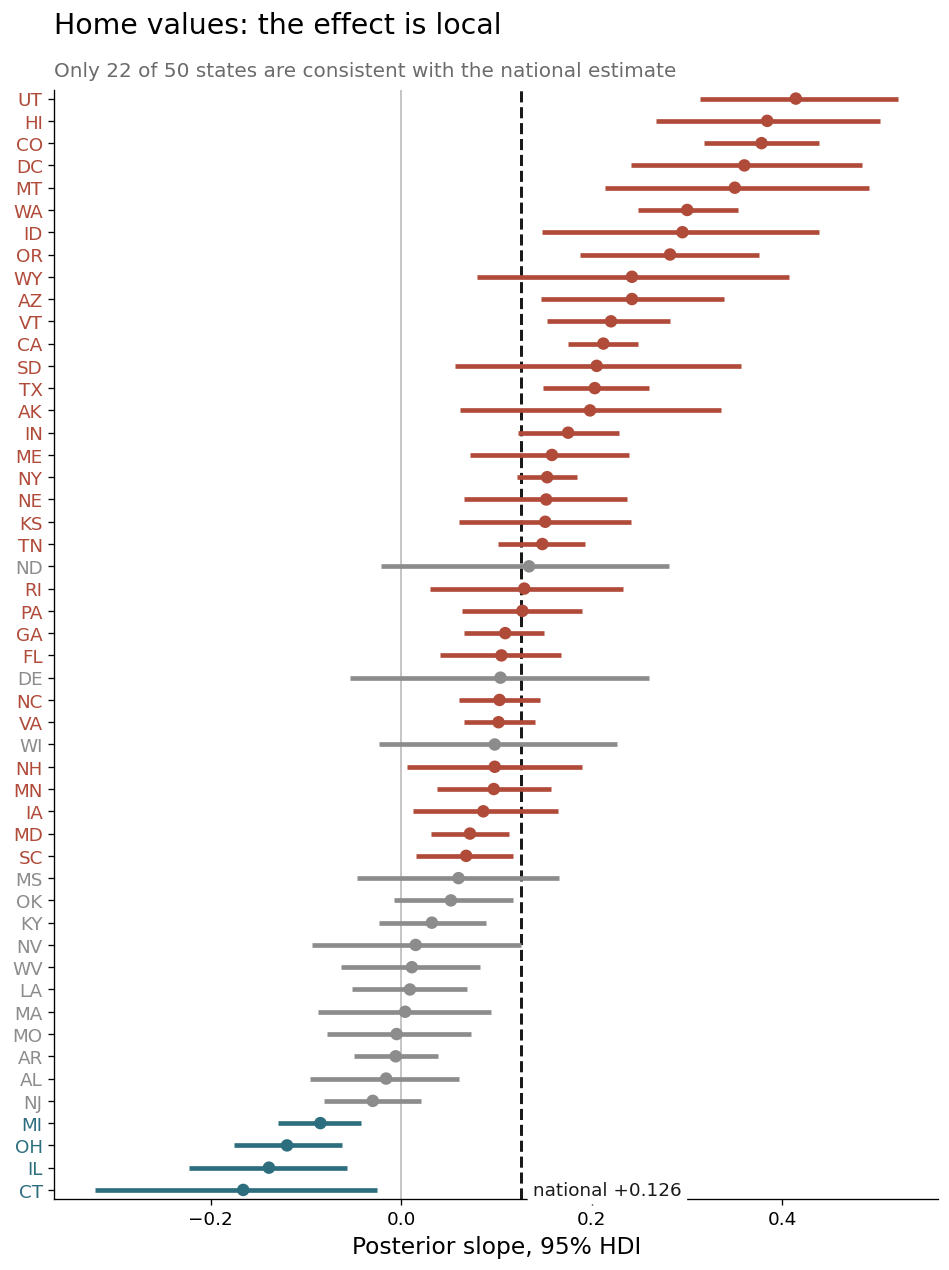

  wrote ../reports/figures/presentation/F6_forest_rents.png


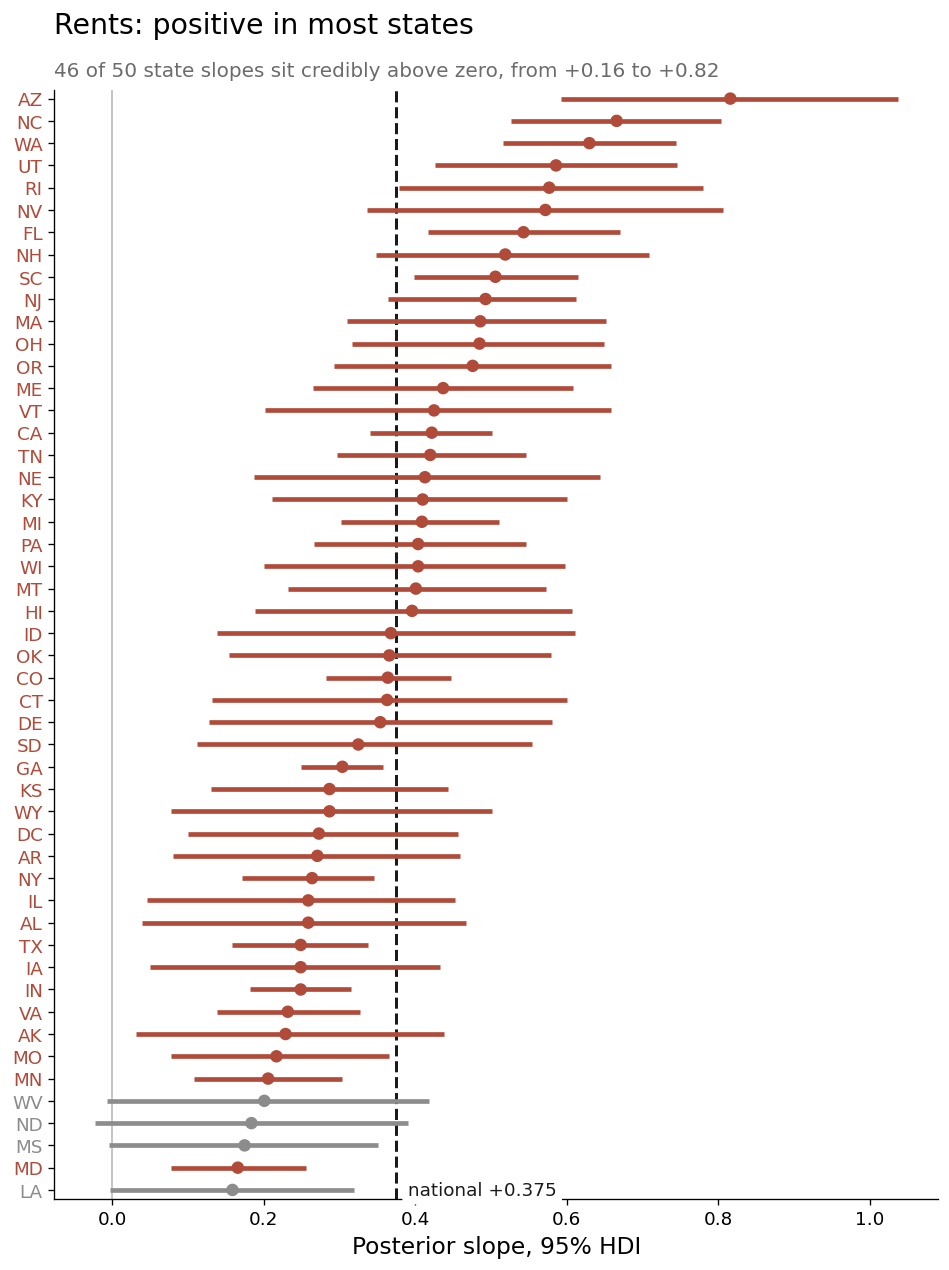

In [11]:
def forest(tier_df, mu, title, subtitle, fname):
    d = tier_df.sort_values('mean')
    cmap = {'positive': C_POS, 'zero': C_ZERO, 'negative': C_NEG}
    cols = d['tier'].map(cmap)
    y = np.arange(len(d))

    fig, ax = plt.subplots(figsize=(9.5, 12))
    ax.axvline(0, color='#BBBBBB', lw=1.0, ls='-', zorder=1)
    ax.axvline(mu, color=C_INK, lw=1.8, ls='--', zorder=2)

    ax.errorbar(d['mean'], y,
                xerr=[d['mean'] - d['hdi_2.5%'], d['hdi_97.5%'] - d['mean']],
                fmt='none', ecolor=cols, elinewidth=2.8, capsize=0, zorder=3)
    ax.scatter(d['mean'], y, s=42, color=cols, zorder=4)

    ax.set_yticks(y)
    ax.set_yticklabels(d.index)
    for lbl, c in zip(ax.get_yticklabels(), cols):
        lbl.set_color(c)
    ax.set_xlabel('Posterior slope, 95% HDI')
    ax.set_title(title, loc='left')
    ax.text(0, 1.012, subtitle, transform=ax.transAxes,
            fontsize=12, color='#6B6B6B')
    ax.annotate(f'national {mu:+.3f}', xy=(mu, 0.0),
                xytext=(7, 0), textcoords='offset points',
                color=C_INK, fontsize=11, ha='left', va='center',
                bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='none'))
    ax.margins(y=0.008)
    save(fig, fname)
    plt.show()


n_contains_h = ((h_tier['hdi_2.5%'] < MU_H) & (h_tier['hdi_97.5%'] > MU_H)).sum()
forest(h_tier, MU_H,
       'Home values: the effect is local',
       f'Only {n_contains_h} of {len(h_tier)} states are consistent with the '
       f'national estimate',
       'F5_forest_home_values')

n_contains_r = ((r_tier['hdi_2.5%'] < MU_R) & (r_tier['hdi_97.5%'] > MU_R)).sum()
n_pos_r = (r_tier['tier'] == 'positive').sum()
forest(r_tier, MU_R,
       'Rents: positive in most states',
       f'{n_pos_r} of {len(r_tier)} state slopes sit credibly above zero, from '
       f'{r_tier["mean"].min():+.2f} to {r_tier["mean"].max():+.2f}',
       'F6_forest_rents')

## Step 9 — F7: the tier summary

The number that anchors slide 7. Rendered as a figure so it drops straight onto a
slide with the same typography as the charts.

  wrote ../reports/figures/presentation/F7_tier_summary.png


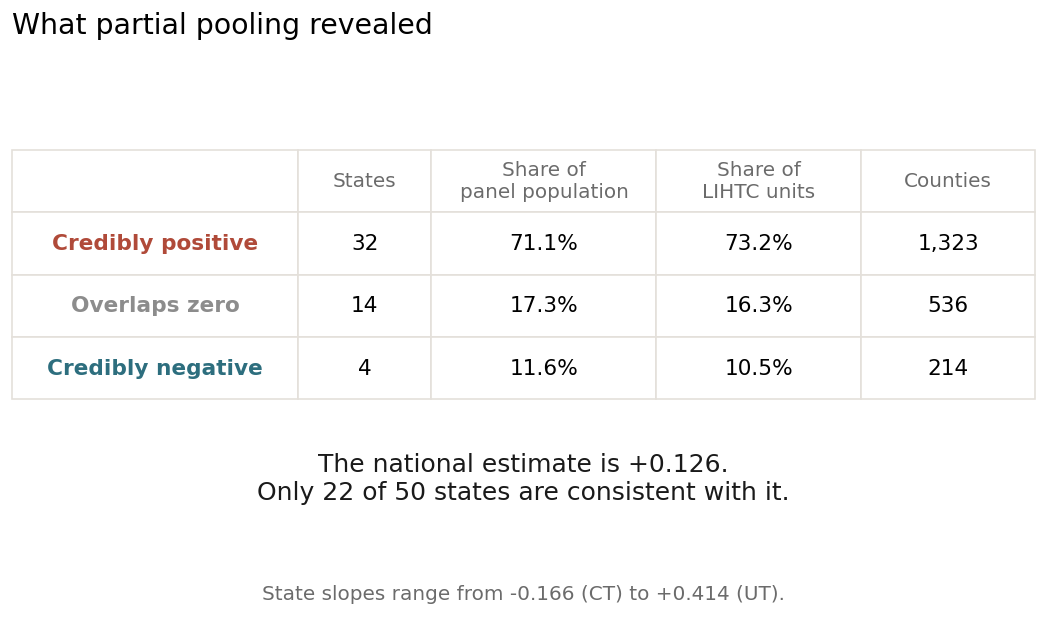

In [12]:
fig, ax = plt.subplots(figsize=(11, 5.4))
ax.axis('off')

rows, cols_ = [], ['', 'States', 'Share of\npanel population',
                   'Share of\nLIHTC units', 'Counties']
labels = {'positive': 'Credibly positive',
          'zero':     'Overlaps zero',
          'negative': 'Credibly negative'}
tier_cols = {'positive': C_POS, 'zero': C_ZERO, 'negative': C_NEG}

for t in order:
    r = summary.loc[t]
    rows.append([labels[t], f'{int(r.states):,}', f'{r.pop_share:.1%}',
                 f'{r.unit_share:.1%}', f'{int(r.counties):,}'])

tbl = ax.table(cellText=rows, colLabels=cols_, cellLoc='center',
               colWidths=[0.28, 0.13, 0.22, 0.20, 0.17],
               bbox=[0.0, 0.42, 1.0, 0.50])
tbl.auto_set_font_size(False)
tbl.set_fontsize(13)

for (row, col), cell in tbl.get_celld().items():
    cell.set_edgecolor('#E4E0DA')
    if row == 0:
        cell.set_text_props(color='#6B6B6B', fontsize=12)
        cell.set_facecolor('white')
    elif col == 0:
        cell.set_text_props(color=tier_cols[order[row - 1]], fontweight='bold')

ax.text(0.5, 0.22,
        f'The national estimate is {MU_H:+.3f}.\n'
        f'Only {n_contains_h} of {N_STATES} states are consistent with it.',
        transform=ax.transAxes, ha='center', fontsize=15, color=C_INK)
ax.text(0.5, 0.02,
        f'State slopes range from {h_tier["mean"].min():+.3f} '
        f'({h_tier["mean"].idxmin()}) to {h_tier["mean"].max():+.3f} '
        f'({h_tier["mean"].idxmax()}).',
        transform=ax.transAxes, ha='center', fontsize=12, color='#6B6B6B')

ax.set_title('What partial pooling revealed', loc='left', y=1.04)
save(fig, 'F7_tier_summary')
plt.show()

In [13]:
# Does market expansion explain the split in state slopes?
growth = (housing.groupby('State')
                 .agg(pop_growth=('pop_growth', 'mean'),
                      log_price=('log_zhvi_adj', 'mean')))
chk = h_slopes[['mean']].join(growth).dropna()

print(f"corr(slope, mean population growth) = {chk['mean'].corr(chk['pop_growth']):+.3f}")
print(f"corr(slope, price level)            = {chk['mean'].corr(chk['log_price']):+.3f}")
print()
print('highest-growth states:')
print(chk.nlargest(8, 'pop_growth').to_string(float_format=lambda v: f'{v:+.4f}'))
print('\nlowest-growth states:')
print(chk.nsmallest(8, 'pop_growth').to_string(float_format=lambda v: f'{v:+.4f}'))

corr(slope, mean population growth) = +0.505
corr(slope, price level)            = +0.482

highest-growth states:
         mean  pop_growth  log_price
State                               
ND    +0.1340     +0.0213   +11.9623
UT    +0.4140     +0.0183   +12.1346
FL    +0.1050     +0.0172   +11.9082
ID    +0.2950     +0.0152   +11.8784
TX    +0.2030     +0.0150   +11.7374
AZ    +0.2420     +0.0150   +11.9794
NV    +0.0150     +0.0130   +12.1331
CO    +0.3780     +0.0126   +12.3309

lowest-growth states:
         mean  pop_growth  log_price
State                               
MS    +0.0600     -0.0023   +11.4578
WV    +0.0110     -0.0015   +11.3147
NY    +0.1530     +0.0011   +11.9977
MI    -0.0850     +0.0012   +11.5656
RI    +0.1290     +0.0012   +12.2896
OH    -0.1200     +0.0016   +11.4675
KS    +0.1510     +0.0021   +11.4120
CT    -0.1660     +0.0021   +12.2396


In [14]:
z = lambda v: (v - v.mean()) / v.std()
Xz = np.column_stack([z(chk['pop_growth']), z(chk['log_price'])])
bz, *_ = np.linalg.lstsq(Xz, z(chk['mean']), rcond=None)

print(f"corr(growth, price level)  = {chk['pop_growth'].corr(chk['log_price']):+.3f}")
print(f"standardised beta, growth  = {bz[0]:+.3f}")
print(f"standardised beta, price   = {bz[1]:+.3f}")

corr(growth, price level)  = +0.287
standardised beta, growth  = +0.400
standardised beta, price   = +0.367


In [15]:
chk.to_csv('chk_growth_price.csv')

## Step 10 — Export the backing numbers

A tidy CSV of everything behind F5 through F7, so any number you say out loud on
the day can be traced back without opening a notebook.

In [16]:
export = h_tier[['mean', 'hdi_2.5%', 'hdi_97.5%', 'tier',
                 'population', 'units', 'n_cty', 'pop_share', 'unit_share']]
export = export.join(nopool[['n_obs', 'slope', 'ci_width']]
                     .rename(columns={'slope': 'ols_slope',
                                      'ci_width': 'ols_ci_width'}))
export = export.sort_values('mean', ascending=False)
export.to_csv(f'{OUT_DIR}/state_slope_table.csv')

print(f'wrote {OUT_DIR}/state_slope_table.csv')
print(f'\nall figures in {OUT_DIR}/')
for f in sorted(os.listdir(OUT_DIR)):
    print(f'  {f}')

wrote ../reports/figures/presentation/state_slope_table.csv

all figures in ../reports/figures/presentation/
  F1_coverage_by_state.png
  F2_pooled_slope_over_scatter.png
  F3_no_pooling_estimates.png
  F4_shrinkage.png
  F5_forest_home_values.png
  F6_forest_rents.png
  F7_tier_summary.png
  state_slope_table.csv
